In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np

csv_path = "../output/benchmark_summary.csv"
img_dir = "../output"
if not os.path.exists(csv_path):
    print(f"Error: {csv_path} couldn't be found")

else:
    #load the benchmark content
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded the benchmark content for {len(df)} models")
    display(df.head())

Successfully loaded the benchmark content for 12 models


,model,total_questions,accuracy_pct,avg_score,hallucination_pct,markdown_pass_pct,avg_ttft_ms,avg_latency_ms,total_prompt_tokens,total_completion_tokens,total_cost_usd
0,openai/gpt-4o-mini,150,87.33,87.87,12.67,97.33,1595.28,2561.89,346718,17165,0.0623
1,google/gemini-2.5-flash,150,94.67,94.67,5.33,92.00,925.78,1894.16,388398,31769,0.0773
2,google/gemini-2.5-flash-lite,150,88.67,89.87,11.33,94.67,1001.14,1591.49,388398,28655,0.0377
3,meta-llama/llama-3.3-70b-instruct,150,87.33,88.70,12.00,97.33,1687.90,6772.77,351598,23042,0.0491
4,meta-llama/llama-3.2-3b-instruct,150,64.67,67.40,33.33,98.67,955.65,3524.21,352133,14653,0.0113


C:\Users\alexh\AppData\Local\Temp\ipykernel_23240\1841021729.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_acc["model"], rotation = 45, ha = "right")


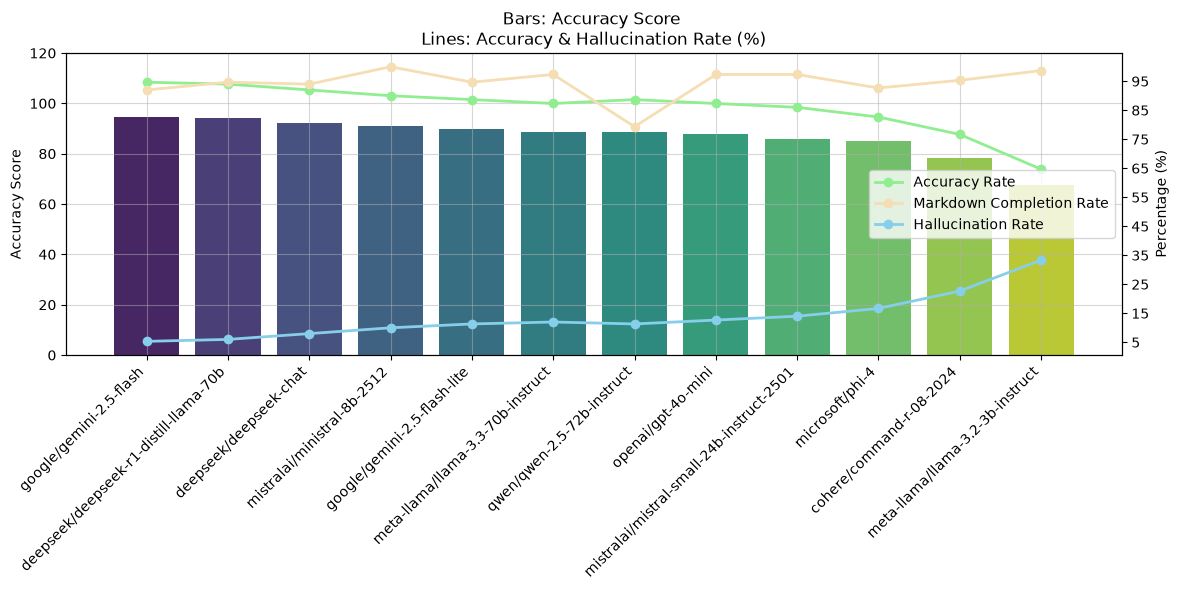

In [23]:
df_acc = df.sort_values(by = "avg_score", ascending=False)

_, ax1 = plt.subplots(figsize = (12, 6))
sns.barplot(
    data = df_acc,
    x = "model",
    hue = "model",
    y = "avg_score",
    ax = ax1,
    palette = "viridis",
    legend = False,
)

ax1.set_ylabel("Accuracy Score")
ax1.set_xticklabels(df_acc["model"], rotation = 45, ha = "right")
ax1.grid(True, alpha= 0.5)
ax1.set_xlabel("")
ax1.set_ylim(0, 120)

ax2 = ax1.twinx()
#Add linegraph for accuracy percentage
ax2.plot(
    df_acc["model"],
    df_acc["accuracy_pct"],
    color = "lightgreen",
    marker = "o",
    linewidth = 2,
    label = "Accuracy Rate",
)

#add linegraph for markdown completion rate
ax2.plot(
    df_acc["model"],
    df_acc["markdown_pass_pct"],
    color = "wheat",
    marker = "o",
    linewidth = 2,
    label = "Markdown Completion Rate",
)

#add linegraph for hallucination rate 
ax2.plot(
    df_acc["model"],
    df_acc["hallucination_pct"],
    color = "skyblue",
    marker = "o",
    linewidth = 2,
    label = "Hallucination Rate",
)

ax2.set_ylabel("Percentage (%)")
ax2.set_yticks(np.arange(5, 96, 10))
plt.title("Bars: Accuracy Score \n" \
        "Lines: Accuracy & Hallucination Rate (%)")
plt.legend(loc = "center right")
plt.tight_layout()
plt.savefig(os.path.join(img_dir, "accuracy_score_rate.png"))
plt.show()

C:\Users\alexh\AppData\Local\Temp\ipykernel_23240\250769313.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")


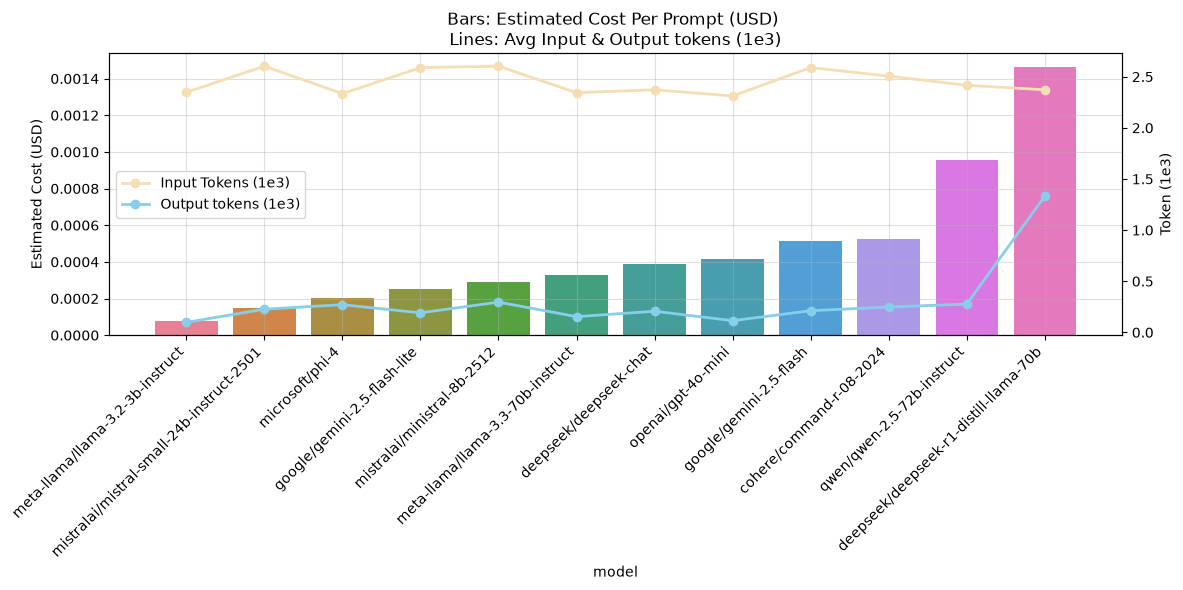

In [22]:
# Sort Data Frame by estimated cost in ascending order
df_cost = df.sort_values(by = "total_cost_usd", ascending=True)
df_cost["total_cost_usd"] = df_cost["total_cost_usd"] / 150

#Plot estimated cost 
_, ax1 = plt.subplots(figsize = (12, 6))
sns.barplot(
    data = df_cost,
    x = "model",
    y = "total_cost_usd",
    ax = ax1,
    hue = "model",
    legend = False,
)
ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")
ax1.set_ylabel("Estimated Cost (USD)")
ax1.grid(True, alpha = 0.4)

#Plot average input token cost
ax2 = ax1.twinx()
ax2.plot(
    df_cost["model"],
    df_cost["total_prompt_tokens"] / int(1e3) / 150,
    marker = 'o',
    color = "wheat",
    linewidth = 2,
    label = "Input Tokens (1e3)"
)

#plot average output token cost 
ax2.plot(
    df_cost["model"],
    df_cost["total_completion_tokens"] / int(1e3) / 150,
    marker = 'o',
    linewidth = 2,
    color = "skyblue",
    label = "Output tokens (1e3)",
)
ax2.set_ylabel("Token (1e3)")

plt.legend(loc = 'center left')
plt.title("Bars: Estimated Cost Per Prompt (USD) \n" \
        "Lines: Avg Input & Output tokens (1e3)")
plt.tight_layout()
plt.savefig (
    os.path.join(img_dir, "estimated_cost_avg_tokens.png"),
)
plt.show()

C:\Users\alexh\AppData\Local\Temp\ipykernel_23240\2245264572.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")


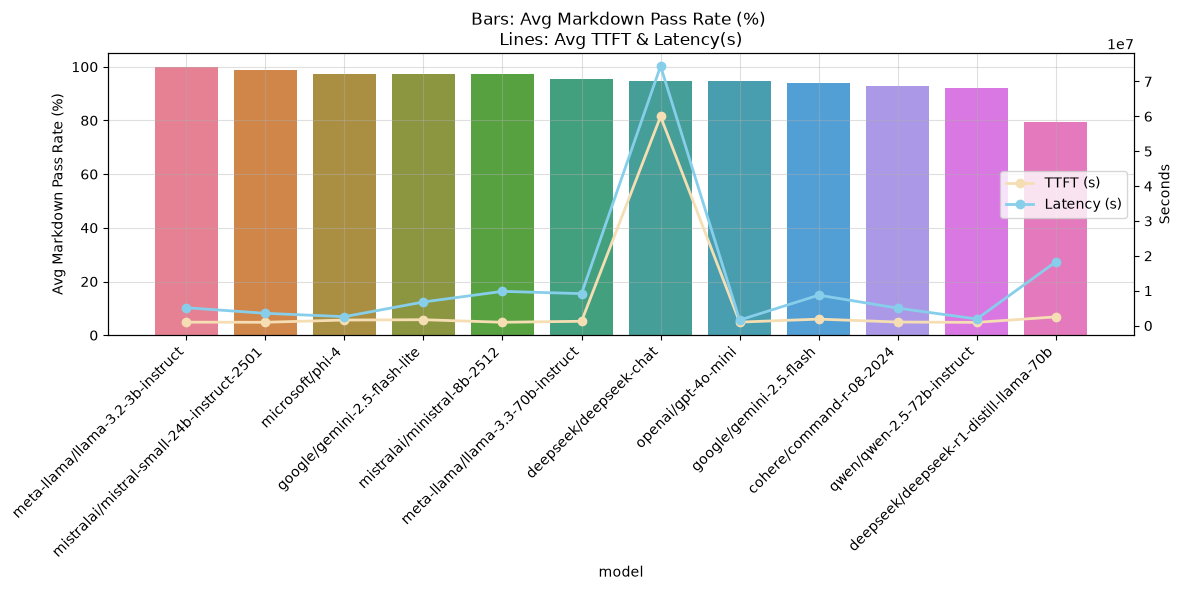

In [19]:
df_md_rate = df.sort_values(by = "markdown_pass_pct", ascending = False)

_, ax1 = plt.subplots(figsize = (12, 6))

#Create bar chart for markdown completion rate
sns.barplot(
    df_md_rate,
    x = "model",
    y = "markdown_pass_pct",
    ax = ax1,
    hue = "model",
    legend = False,
)

ax1.set_xticklabels(df_cost["model"], rotation = 45, ha = "right")
ax1.set_ylabel("Avg Markdown Pass Rate (%)")
ax1.grid(True, alpha = 0.4)

#Plot average input token cost
ax2 = ax1.twinx()
ax2.plot(
    df_md_rate["model"],
    df_md_rate["avg_ttft_ms"] * 1000,
    marker = 'o',
    color = "wheat",
    linewidth = 2,
    label = "TTFT (s)"
)

#plot average latency & ttft
ax2.plot(
    df_md_rate["model"],
    df_md_rate["avg_latency_ms"] * 1000,
    marker = 'o',
    linewidth = 2,
    color = "skyblue",
    label = "Latency (s)",
)
ax2.set_ylabel("Seconds")

plt.legend(loc = 'center right')
plt.title("Bars: Avg Markdown Pass Rate (%) \n" \
        "Lines: Avg TTFT & Latency(s)")
plt.tight_layout()
plt.savefig (
    os.path.join(img_dir, "estimated_md_pass_tfft_latency.png"),
)
plt.show()